In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Setup giao diện
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

# 1. Load dữ liệu
df = pd.read_csv('../data/processed/MultiUser_VitalSigns.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 2. Chọn User có nhiều dữ liệu nhất để demo (User 8792009665)
user_id = 8792009665
raw_df = df[df['Id'] == user_id].sort_values('Timestamp').set_index('Timestamp')

print(f"Data Loaded for User {user_id}: {len(raw_df)} rows")
raw_df[['Heart_Rate', 'Steps']].head()

Data Loaded for User 8792009665: 12099 rows


,Heart_Rate,Steps
Timestamp,,
2016-04-01 00:00:00,81.000000,0.066667
2016-04-01 00:01:00,82.714286,0.066667
2016-04-01 00:02:00,80.833333,0.066667
2016-04-01 00:03:00,80.000000,0.066667
2016-04-01 00:04:00,82.333333,0.066667


Phát hiện 0 điểm dữ liệu bất thường (Outliers).


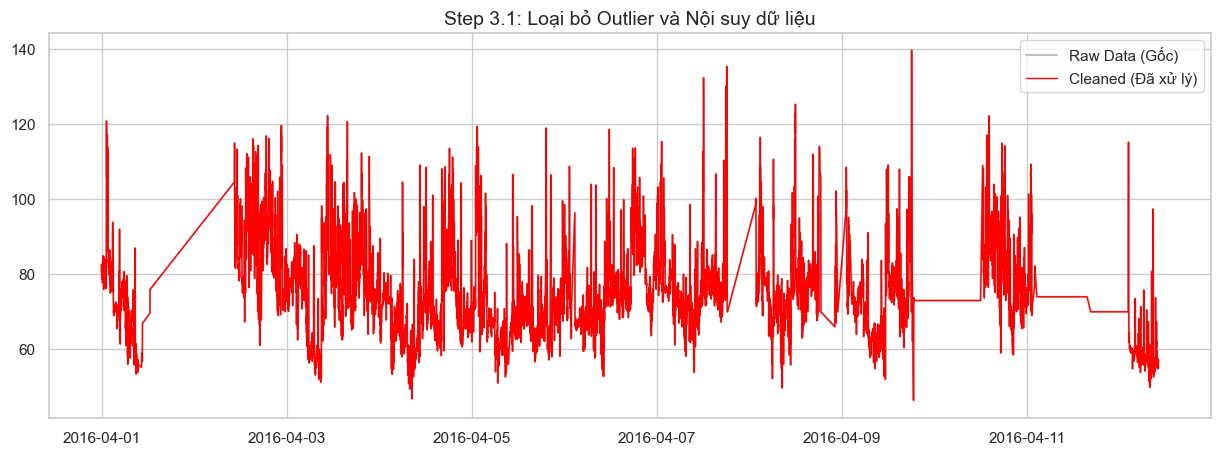

In [2]:
def preprocess_vital_signs(df, hr_col='Heart_Rate', low_limit=40, high_limit=180):
    """
    Hàm làm sạch dữ liệu:
    1. Loại bỏ HR phi lý (nhỏ hơn 40 hoặc lớn hơn 180)
    2. Nội suy (Interpolate) các điểm bị thiếu
    """
    df_clean = df.copy()
    
    # 1. Đếm số lượng Outlier
    outliers = df_clean[(df_clean[hr_col] < low_limit) | (df_clean[hr_col] > high_limit)]
    print(f"Phát hiện {len(outliers)} điểm dữ liệu bất thường (Outliers).")
    
    # 2. Thay thế bằng NaN
    mask = (df_clean[hr_col] < low_limit) | (df_clean[hr_col] > high_limit)
    df_clean.loc[mask, hr_col] = np.nan
    
    # 3. Nội suy tuyến tính (Linear Interpolation) để lấp đầy khoảng trống
    # limit_direction='both' giúp điền cả đầu và đuôi
    df_clean[hr_col] = df_clean[hr_col].interpolate(method='linear', limit_direction='both')
    
    return df_clean

# Áp dụng hàm
clean_df = preprocess_vital_signs(raw_df)

# Vẽ so sánh Trước và Sau (Zoom vào đoạn có outlier nếu có, hoặc đoạn bất kỳ)
plt.figure(figsize=(15, 5))
plt.plot(raw_df.index, raw_df['Heart_Rate'], label='Raw Data (Gốc)', color='gray', alpha=0.5)
plt.plot(clean_df.index, clean_df['Heart_Rate'], label='Cleaned (Đã xử lý)', color='red', linewidth=1)
plt.title('Step 3.1: Loại bỏ Outlier và Nội suy dữ liệu', fontsize=14)
plt.legend()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_26548\924881485.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_day_15min = df_day.resample('15T').mean() # 15 phút
C:\Users\Admin\AppData\Local\Temp\ipykernel_26548\924881485.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_day_1h = df_day.resample('1H').mean()     # 1 giờ


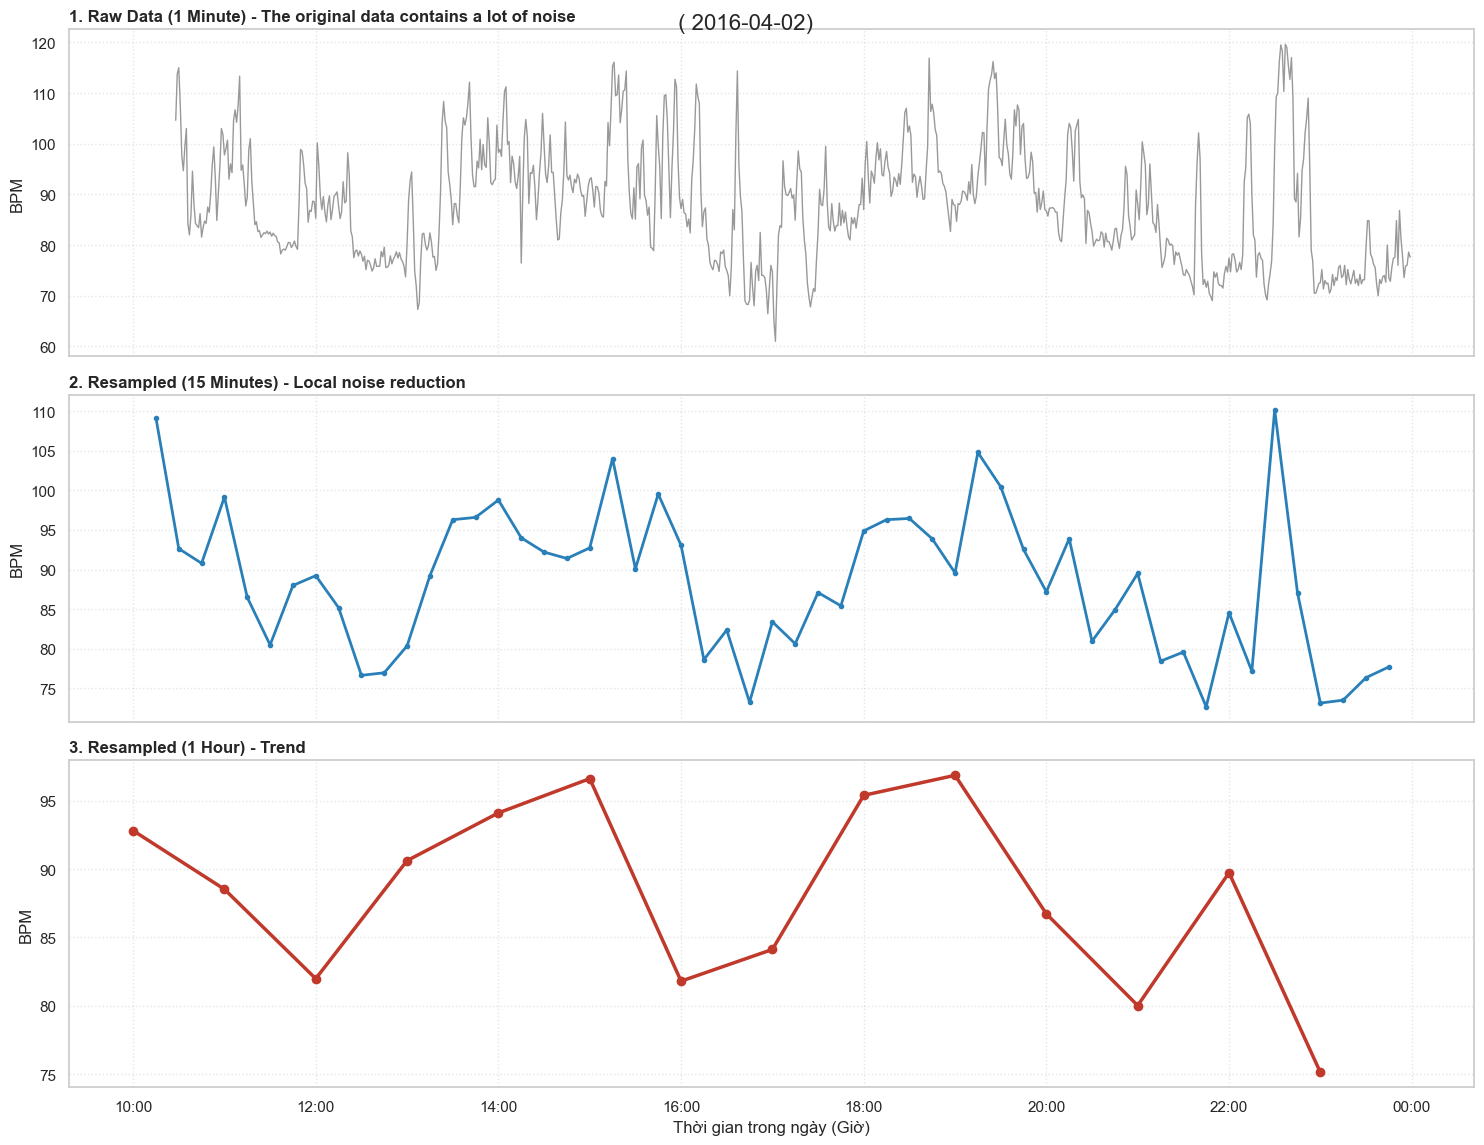

In [6]:
# --- CODE PHẦN RESAMPLING ---

# 1. Chuẩn bị dữ liệu (Lấy lại bước trên)
day_zoom = '2016-04-02'
df_day = clean_df.loc[day_zoom]              # Gốc (1 phút)
df_day_15min = df_day.resample('15T').mean() # 15 phút
df_day_1h = df_day.resample('1H').mean()     # 1 giờ

# 2. Tạo khung vẽ: 3 dòng, 1 cột, chia sẻ trục X (sharex=True)
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# --- BIỂU ĐỒ 1: RAW DATA (Dữ liệu thô) ---
axes[0].plot(df_day.index, df_day['Heart_Rate'], 
             color='gray', alpha=0.8, linewidth=1)
axes[0].set_title(f'1. Raw Data (1 Minute) - The original data contains a lot of noise', fontsize=12, fontweight='bold', loc='left')
axes[0].set_ylabel('BPM')
axes[0].grid(True, linestyle=':', alpha=0.5)

# --- BIỂU ĐỒ 2: RESAMPLE 15 MIN ---
axes[1].plot(df_day_15min.index, df_day_15min['Heart_Rate'], 
             color='#2980b9', linewidth=2, marker='.')
axes[1].set_title(f'2. Resampled (15 Minutes) - Local noise reduction', fontsize=12, fontweight='bold', loc='left')
axes[1].set_ylabel('BPM')
axes[1].grid(True, linestyle=':', alpha=0.5)

# --- BIỂU ĐỒ 3: RESAMPLE 1 HOUR (Trend) ---
axes[2].plot(df_day_1h.index, df_day_1h['Heart_Rate'], 
             color='#c0392b', linewidth=2.5, marker='o', linestyle='-')
axes[2].set_title(f'3. Resampled (1 Hour) - Trend', fontsize=12, fontweight='bold', loc='left')
axes[2].set_ylabel('BPM')
axes[2].set_xlabel('Thời gian trong ngày (Giờ)', fontsize=12)
axes[2].grid(True, linestyle=':', alpha=0.5)

# Định dạng trục thời gian (Chỉ cần làm cho biểu đồ cuối cùng vì sharex=True)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.suptitle(f' ( {day_zoom})', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_26548\3430111720.py:12: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)


Tổng số phút bị thiếu dữ liệu ban đầu (sau khi reindex): 4343
Số phút vẫn còn là NaN (Gap lớn > 5 phút): 4201
-> Nếu số NaN còn lại > 0, chứng tỏ code đã hoạt động đúng (không lấp liếm các gap to).


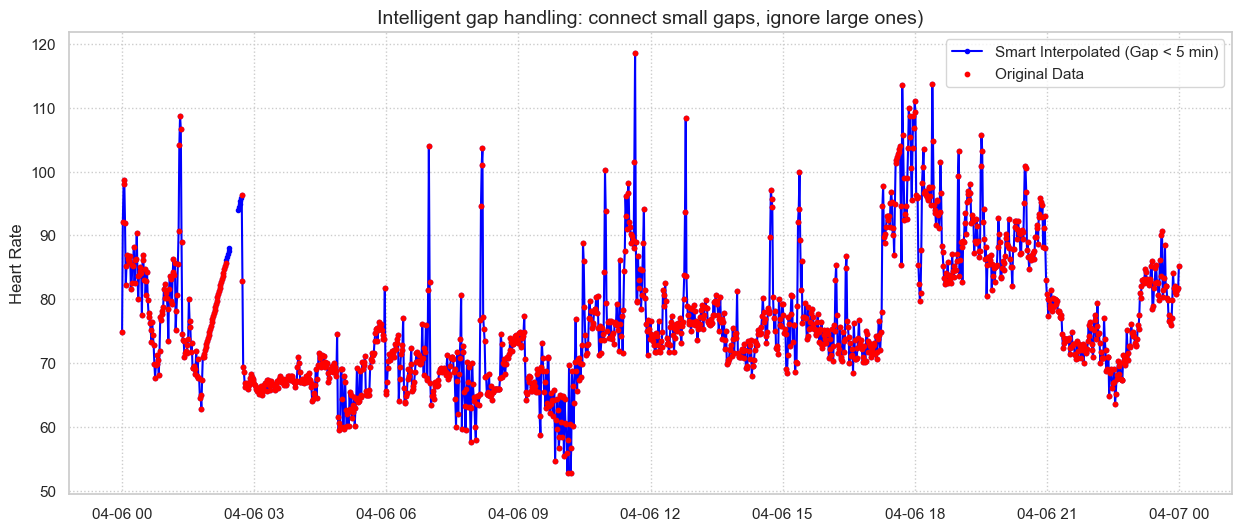

In [5]:
# --- TASK 1.3: HANDLING GAPS (XỬ LÝ KHOẢNG NGẮT QUÃNG) ---

def handle_gaps_smartly(df, freq='1T', max_gap_fill_minutes=5):
    """
    Hàm xử lý khoảng trống thông minh:
    1. Reindex lại đầy đủ từng phút (để lộ ra các dòng bị thiếu).
    2. Chỉ nội suy nếu khoảng trống nhỏ hơn ngưỡng (ví dụ 5 phút).
    3. Khoảng trống lớn giữ nguyên là NaN (để tách Segment sau này).
    """
    # 1. Reindex để đảm bảo liên tục từng phút
    # Tạo một index đầy đủ từ đầu đến cuối
    full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)
    df_reindexed = df.reindex(full_idx)
    
    # 2. Nội suy có điều kiện (Limit Area)
    # limit=5: Chỉ điền tối đa 5 giá trị NaN liên tiếp. 
    # Nếu gap > 5 phút, nó sẽ KHÔNG điền gì cả (giữ nguyên NaN).
    df_filled = df_reindexed.interpolate(method='linear', limit=max_gap_fill_minutes, limit_direction='both')
    
    return df_filled, df_reindexed

# Áp dụng hàm (Chỉ lấp gap nhỏ hơn 5 phút, còn gap to kệ nó)
df_gap_handled, df_with_nans = handle_gaps_smartly(clean_df, max_gap_fill_minutes=5)

# --- VISUALIZE ĐỂ KIỂM TRA ---
# Chọn một ngày có gap lớn để check (Ví dụ ngày 06/04 hoặc 07/04)
# Bạn có thể đổi ngày khác để tìm gap
check_start = '2016-04-06 00:00:00'
check_end = '2016-04-07 00:00:00'

subset_original = clean_df[check_start:check_end]
subset_filled = df_gap_handled[check_start:check_end]

plt.figure(figsize=(15, 6))

# Vẽ dữ liệu sau khi xử lý (Màu xanh)
plt.plot(subset_filled.index, subset_filled['Heart_Rate'], 
         label='Smart Interpolated (Gap < 5 min)', color='blue', marker='.', linestyle='-')

# Vẽ điểm dữ liệu gốc đè lên (Màu đỏ chấm)
plt.scatter(subset_original.index, subset_original['Heart_Rate'], 
            color='red', s=10, label='Original Data', zorder=5)

plt.title('Intelligent gap handling: connect small gaps, ignore large ones)', fontsize=14)
plt.ylabel('Heart Rate')
plt.legend()
plt.grid(True, linestyle=':')

# Kiểm tra xem có bao nhiêu gap lớn còn lại (vẫn là NaN)
nan_remaining = df_gap_handled['Heart_Rate'].isnull().sum()
print(f"Tổng số phút bị thiếu dữ liệu ban đầu (sau khi reindex): {df_with_nans['Heart_Rate'].isnull().sum()}")
print(f"Số phút vẫn còn là NaN (Gap lớn > 5 phút): {nan_remaining}")
print("-> Nếu số NaN còn lại > 0, chứng tỏ code đã hoạt động đúng (không lấp liếm các gap to).")

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_26548\4055162637.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = clean_df.resample('1H').mean().interpolate() # Đảm bảo không còn NaN


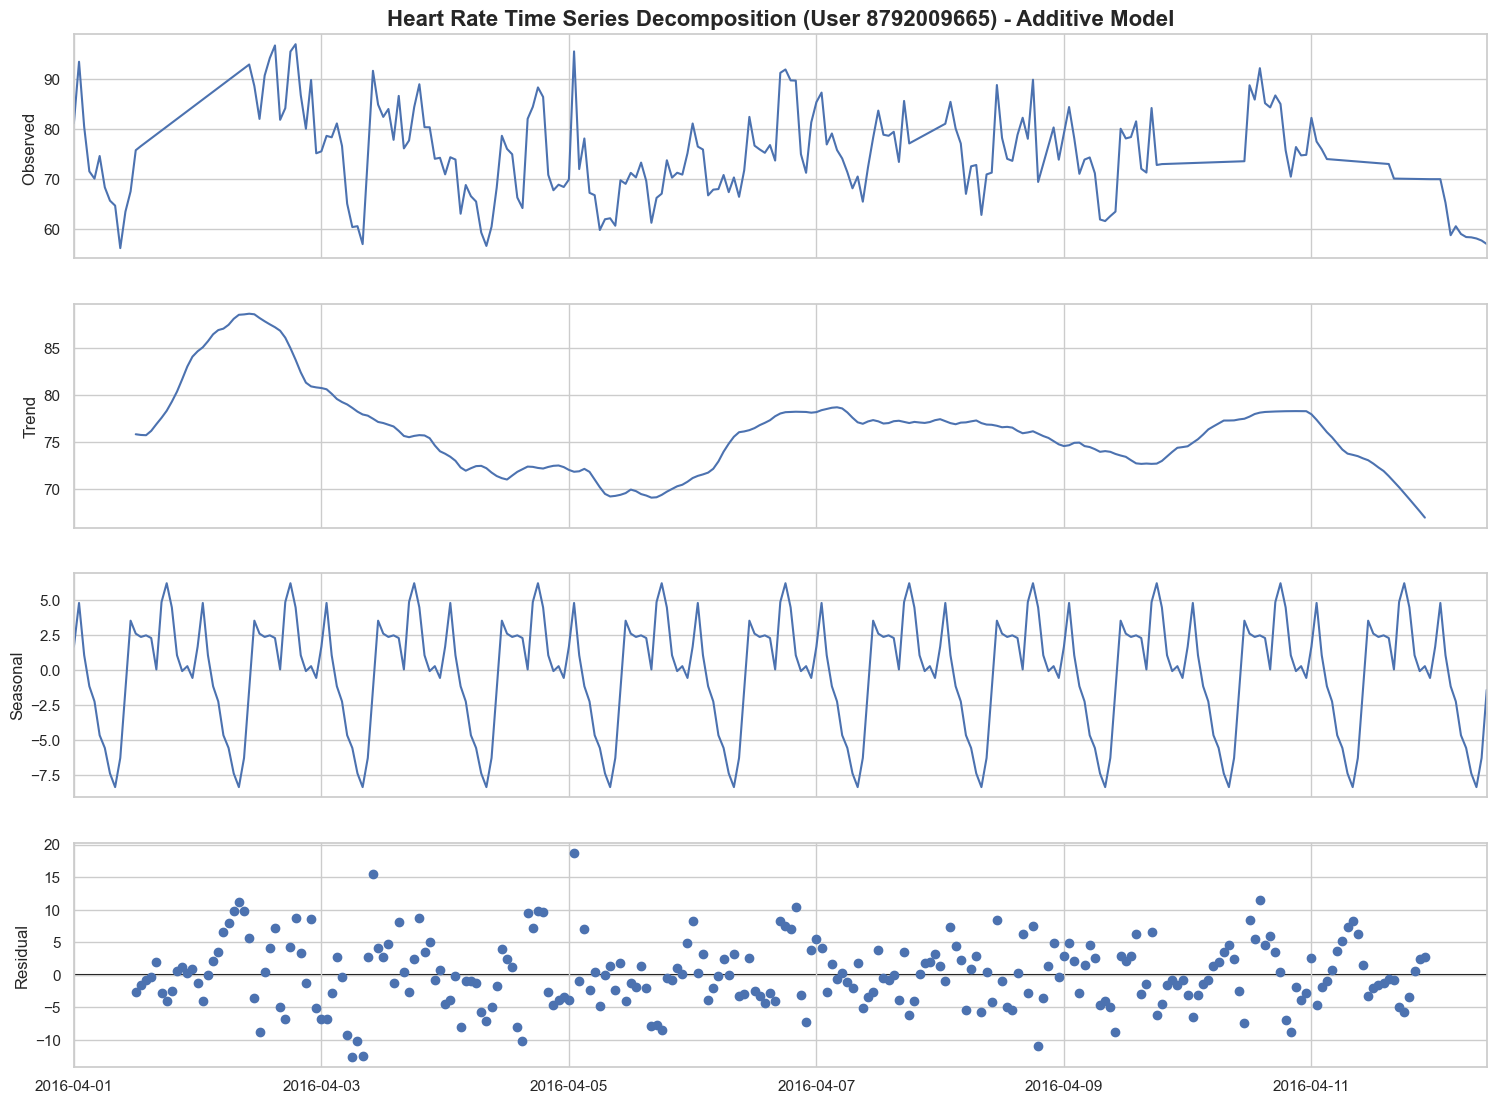

Residual Mean: 0.1032 
Residual Std: 4.9991 


In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# --- TASK 1.4: TIME SERIES DECOMPOSITION ---

# 1. Chuẩn bị dữ liệu (Bắt buộc phải Resample trước)
# Tại sao? Dữ liệu 1 phút quá nhiễu, không phân rã được.
# Ta dùng dữ liệu 1 Giờ (Hourly) để tìm chu kỳ Ngày (24 giờ).
df_hourly = clean_df.resample('1H').mean().interpolate() # Đảm bảo không còn NaN

# 2. Thực hiện phân rã (Decomposition)
# model='additive': Giả định HR = Trend + Seasonal + Residual (Cộng tính)
# period=24: Vì dữ liệu là theo giờ, chu kỳ lặp lại là 24h (1 ngày)
decomposition = seasonal_decompose(df_hourly['Heart_Rate'], model='additive', period=24)

# 3. Vẽ biểu đồ 4 thành phần
fig = decomposition.plot()
fig.set_size_inches(15, 12) # Chỉnh kích thước cho to rõ

# Trang trí lại cho đẹp (Mặc định của thư viện hơi xấu)
axes = fig.axes
axes[0].set_title(f'Heart Rate Time Series Decomposition (User {user_id}) - Additive Model', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Observed ')
axes[1].set_ylabel('Trend')
axes[2].set_ylabel('Seasonal')
axes[3].set_ylabel('Residual')

plt.show()

# 4. Phân tích phần Residual (Quan trọng)
resid_mean = decomposition.resid.mean()
resid_std = decomposition.resid.std()
print(f"Residual Mean: {resid_mean:.4f} ")
print(f"Residual Std: {resid_std:.4f} ")

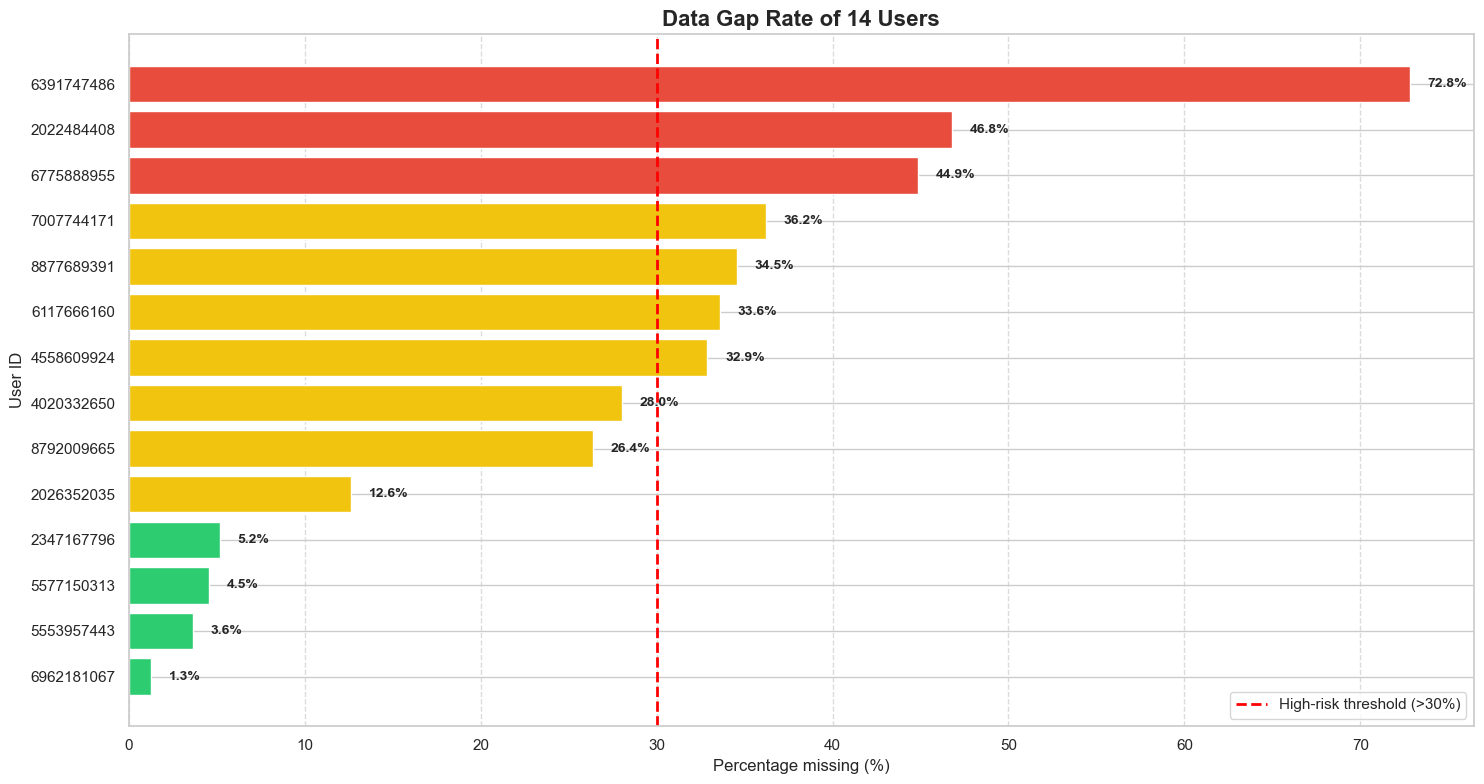

In [9]:
# --- CODE QUÉT GAP CHO TOÀN BỘ 14 USERS ---

# Tạo list để lưu kết quả
gap_stats = []

# Duyệt qua từng User ID
for uid in df['Id'].unique():
    # Lấy dữ liệu của user đó
    user_data = df[df['Id'] == uid]
    
    # Tính thời gian bắt đầu và kết thúc thực tế
    start = user_data['Timestamp'].min()
    end = user_data['Timestamp'].max()
    
    # Tổng số phút lý thuyết (Nếu đeo liên tục 24/7)
    total_minutes = int((end - start).total_seconds() / 60) + 1
    
    # Số phút thực tế có dữ liệu
    actual_records = len(user_data)
    
    # Tính phần trăm bị mất
    missing_pct = 100 * (1 - actual_records / total_minutes)
    
    gap_stats.append({
        'User_ID': str(uid), # Chuyển sang string để vẽ cho dễ
        'Missing_Pct': missing_pct,
        'Total_Days': total_minutes / 1440 # Quy ra ngày cho dễ hình dung
    })

# Chuyển thành DataFrame và sắp xếp
gap_df = pd.DataFrame(gap_stats).sort_values('Missing_Pct', ascending=True)

# --- VẼ BIỂU ĐỒ SO SÁNH ---
plt.figure(figsize=(15, 8))

# Tạo màu: Xanh (Tốt) -> Đỏ (Xấu)
colors = ['#2ecc71' if x < 10 else '#f1c40f' if x < 40 else '#e74c3c' for x in gap_df['Missing_Pct']]

bars = plt.barh(gap_df['User_ID'], gap_df['Missing_Pct'], color=colors)

plt.title('Data Gap Rate of 14 Users', fontsize=16, fontweight='bold')
plt.xlabel('Percentage missing (%)', fontsize=12)
plt.ylabel('User ID', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Thêm nhãn số % vào cuối mỗi thanh
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', va='center', fontsize=10, fontweight='bold')

# Vẽ đường giới hạn 30% (Ngưỡng chấp nhận được)
plt.axvline(30, color='red', linestyle='--', linewidth=2, label='High-risk threshold (>30%)')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()